# 10 · Multimodal analysis: does MKL add anything to functional connectivity?

This is the analysis the whole protocol was written for. Both modalities now exist for the same participants:
- **functional** — 4,950 connectivity edges from the NIAK release (notebook 03b);
- **structural** — 76 regional volumes from FastSurfer segmentation (notebook 02b).

It runs every model in `configs/model_config.yaml` through the same repeated nested cross-validation, applies the prespecified decision rule from protocol §7.3, and runs both permutation nulls.

## What is being tested

**Primary hypothesis (H1).** MKL beats the prespecified functional baseline. The estimand is the mean paired ΔAUC over the outer folds, and the decision rule needs all three of:
1. a positive difference distinguishable from the structural-block null (p < 0.05);
2. a corrected 95% interval whose lower bound is above 0;
3. a mean difference of at least δ = 0.02.

**Secondary (H2).** MKL beats early concatenation, equal-weight fusion, stacking and the structural-only model, Holm-corrected.

**The two nulls, and why they differ.** Permuting labels tests whether a model beats chance. It cannot test H1, because destroying the labels drags *both* models to chance, so their difference centres on zero regardless. The primary null instead permutes the rows of the structural block while keeping labels, connectivity and confounds intact, which asks the right question: does structural MRI carry anything MKL can use?

**Permutations are optional in a given run.** They are the expensive part (roughly an hour at 1,000 each). Set the environment variable `MKL_PERMUTATIONS` to the number wanted; with 0 the notebook reports the estimates and leaves the verdict pending. Chunks are saved separately and combined later, so permutations can be added across sessions.

**Lock status.** The protocol's §14 lock record decides whether this run counts as confirmatory. The cell below reports what it currently says.

In [1]:
from pathlib import Path
from functools import partial
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOKS = ROOT / "notebooks"
RESULTS = ROOT / "results"
TAG = "multimodal"
PERMUTATIONS = int(os.environ.get("MKL_PERMUTATIONS", "0"))
# Parallel workers. Fewer than the full core count leaves thermal headroom on a laptop.
N_JOBS = int(os.environ.get("MKL_JOBS", "-1"))


def use_notebook(name):
    """Run the definition cells (tagged "library") of another notebook in this namespace."""
    notebook = json.loads((NOTEBOOKS / name).read_text(encoding="utf-8"))
    for cell in notebook["cells"]:
        if cell["cell_type"] == "code" and "library" in cell["metadata"].get("tags", []):
            exec("".join(cell["source"]), globals())


def load_yaml(path):
    with open(path, encoding="utf-8") as fh:
        return yaml.safe_load(fh)

In [2]:
use_notebook("07_stability_and_confounds.ipynb")   # stability + metrics + nested CV + models (04-06)

In [3]:
def load_multimodal_design(min_seconds=None, confound_columns=("age", "sex_male", "mean_fd")):
    """Design matrix with blocks structural | functional | confounds for participants with both.

    Rows are the intersection of the functional manifest (after the retained-time rule)
    and the participants with a FastSurfer segmentation. No imputation (protocol §2.5).
    """
    cfg = load_yaml(ROOT / "configs" / "data_config.yaml")
    features_dir = ROOT / cfg["features_dir"]
    manifest = pd.read_csv(ROOT / "data" / "participants_manifest_niak.csv", dtype={"participant_id": str})
    if min_seconds is None:
        min_seconds = cfg["niak"]["qc"]["min_retained_seconds"]
    manifest = manifest[manifest["retained_seconds"] >= min_seconds].copy()
    manifest["num_id"] = manifest["participant_raw"].str.extract(r"(\d{7})")

    functional = pd.read_csv(features_dir / "functional_features_niak.csv", dtype={"participant_id": str})
    structural = pd.read_csv(features_dir / "structural_features_fastsurfer.csv", dtype={"participant_id": str})
    structural["num_id"] = structural["participant_id"].str.extract(r"(\d{7})")
    structural = structural.drop(columns="participant_id")

    design = (manifest.merge(functional, on="participant_id", how="inner", validate="one_to_one")
                      .merge(structural, on="num_id", how="inner", validate="one_to_one"))
    s_cols = [c for c in structural.columns if c != "num_id"]
    f_cols = [c for c in functional.columns if c != "participant_id"]
    X = design[s_cols + f_cols + list(confound_columns)].to_numpy(float)
    if np.isnan(X).any():
        raise ValueError("Missing values in the design matrix (no imputation allowed).")
    blocks, start = {}, 0
    for name, cols in [("structural", s_cols), ("functional", f_cols), ("confounds", list(confound_columns))]:
        blocks[name] = np.arange(start, start + len(cols))
        start += len(cols)
    return X, design["label"].to_numpy(int), design["participant_id"].to_numpy(), blocks, design

## The analysis sample

In [4]:
model_cfg = load_yaml(ROOT / "configs" / "model_config.yaml")
cv_cfg = load_yaml(ROOT / "configs" / "cv_config.yaml")
seeds = read_seeds(ROOT / cv_cfg["seeds_file"])
MODELS = ["structural", "functional", "early_fusion", "equal_weight", "mkl", "stacking", "confounds_only"]

X, y, ids, blocks, design = load_multimodal_design()
print(f"{len(y)} participants: {int(y.sum())} patients, {int((y == 0).sum())} controls")
for name, idx in blocks.items():
    print(f"  {name:11s} {len(idx):5d} features")
implicit = len(blocks["structural"]) / (len(blocks["structural"]) + len(blocks["functional"]))
print(f"implicit structural weight in early fusion: {implicit:.3f}")

lock = [line for line in (ROOT / "protocol" / "protocol.md").read_text(encoding="utf-8").splitlines()
        if line.startswith("| Lock date")]
print("\nprotocol lock record:", lock[0] if lock else "not found")
print("If the lock date is blank, these results are exploratory under protocol §13.")
print(f"permutations this run: {PERMUTATIONS}")

82 participants: 31 patients, 51 controls
  structural     76 features
  functional   4950 features
  confounds       3 features
implicit structural weight in early fusion: 0.015

protocol lock record: | Lock date | |
If the lock date is blank, these results are exploratory under protocol §13.
permutations this run: 0


## Run every model through the nested cross-validation
Identical outer and inner splits for all models, so every comparison below is paired.

In [5]:
import time

start = time.perf_counter()
predictions, selections, weights = run_nested_cv(
    X, y, ids, partial(build_models, model_cfg, blocks, include=MODELS), seeds,
    cv_cfg["outer"]["n_splits"], cv_cfg["inner"]["n_splits"], n_jobs=N_JOBS, collect_weights=True)
folds = fold_metrics(predictions)
print(f"{len(MODELS)} models x {len(seeds)} repeats x {cv_cfg['outer']['n_splits']} folds "
      f"in {time.perf_counter() - start:.0f} s")
display(summarize(folds).round(3))

7 models x 10 repeats x 5 folds in 14 s


,model,auc_mean,auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,prevalence_mean,prevalence_std
0,structural,0.662,0.114,0.663,0.116,0.566,0.094,0.418,0.325,0.715,0.267,0.378,0.019
1,functional,0.688,0.132,0.655,0.142,0.598,0.094,0.616,0.245,0.579,0.235,0.378,0.019
2,early_fusion,0.695,0.138,0.655,0.152,0.610,0.104,0.652,0.230,0.569,0.262,0.378,0.019
3,equal_weight,0.687,0.118,0.653,0.130,0.607,0.108,0.587,0.297,0.628,0.266,0.378,0.019
4,mkl,0.689,0.113,0.654,0.128,0.603,0.083,0.599,0.276,0.607,0.238,0.378,0.019
5,stacking,0.658,0.187,0.625,0.167,0.604,0.101,0.536,0.326,0.672,0.255,0.378,0.019
6,confounds_only,0.487,0.155,0.461,0.122,0.490,0.100,0.499,0.388,0.481,0.348,0.378,0.019


## What weights did MKL choose?
β is the share of the combined kernel given to the structural block. Early fusion's implicit weight is shown for contrast: it is fixed by the feature counts, not learned.

MKL β_structural: median 0.30, mean 0.34, range 0.0–1.0
folds where β_structural = 0 (MKL reduced to the functional model): 12%
folds where β_structural = 1 (MKL reduced to the structural model): 2%


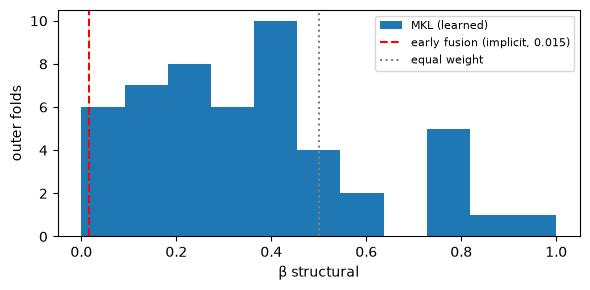

In [6]:
beta = selections[selections["model"] == "mkl"]["beta_structural"]
print(f"MKL β_structural: median {beta.median():.2f}, mean {beta.mean():.2f}, "
      f"range {beta.min():.1f}–{beta.max():.1f}")
print(f"folds where β_structural = 0 (MKL reduced to the functional model): {(beta == 0).mean():.0%}")
print(f"folds where β_structural = 1 (MKL reduced to the structural model): {(beta == 1).mean():.0%}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(beta, bins=11, range=(0, 1), label="MKL (learned)")
ax.axvline(implicit, color="red", ls="--", label=f"early fusion (implicit, {implicit:.3f})")
ax.axvline(0.5, color="grey", ls=":", label="equal weight")
ax.set(xlabel="β structural", ylabel="outer folds")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Primary comparison: MKL versus functional connectivity
The interval uses the Nadeau–Bengio correction, because the 50 folds share training data and a naive interval would be far too narrow.

mean ΔAUC (MKL − functional) = +0.0009
corrected 95% CI = [-0.1287, +0.1305]
δ (minimum meaningful difference) = 0.02
folds where MKL > functional: 52%


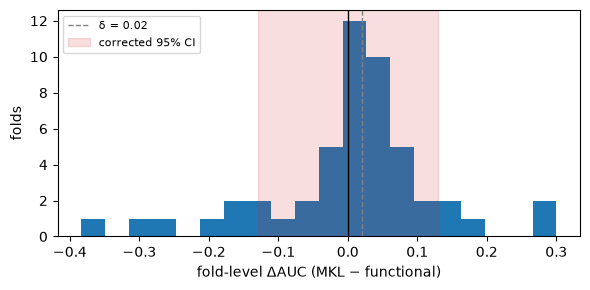

In [7]:
ratio = 1 / (cv_cfg["outer"]["n_splits"] - 1)
alpha = cv_cfg["inference"]["alpha"]
delta = cv_cfg["inference"]["min_meaningful_delta_auc"]
primary_diff = paired_differences(folds, "mkl", "functional")
primary_ci = corrected_resampled_ci(primary_diff, ratio, alpha)
print(f"mean ΔAUC (MKL − functional) = {primary_ci['mean']:+.4f}")
print(f"corrected 95% CI = [{primary_ci['ci_low']:+.4f}, {primary_ci['ci_high']:+.4f}]")
print(f"δ (minimum meaningful difference) = {delta}")
print(f"folds where MKL > functional: {(primary_diff > 0).mean():.0%}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(primary_diff, bins=20)
ax.axvline(0, color="k", lw=1)
ax.axvline(delta, color="grey", ls="--", lw=1, label=f"δ = {delta}")
ax.axvspan(primary_ci["ci_low"], primary_ci["ci_high"], color="tab:red", alpha=0.15, label="corrected 95% CI")
ax.set(xlabel="fold-level ΔAUC (MKL − functional)", ylabel="folds")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Secondary comparisons (Holm-corrected)

In [8]:
rows = []
for comparator in ["early_fusion", "equal_weight", "stacking", "structural"]:
    ci = corrected_resampled_ci(paired_differences(folds, "mkl", comparator), ratio, alpha)
    rows.append({"comparator": comparator, "mean_delta_auc": ci["mean"],
                 "ci_low": ci["ci_low"], "ci_high": ci["ci_high"], "p_raw": ci["p_two_sided"]})
secondary = pd.DataFrame(rows)
adjusted = holm(dict(zip(secondary["comparator"], secondary["p_raw"])))
secondary["p_holm"] = secondary["comparator"].map(adjusted)
display(secondary.round(4))

,comparator,mean_delta_auc,ci_low,ci_high,p_raw,p_holm
0,early_fusion,-0.0056,-0.1286,0.1173,0.9274,1.0
1,equal_weight,0.0024,-0.0795,0.0844,0.9529,1.0
2,stacking,0.0314,-0.1865,0.2494,0.7732,1.0
3,structural,0.0271,-0.1067,0.1610,0.6853,1.0


## Permutation tests
Two nulls, each re-running the complete nested pipeline for every permutation:
- **structural-block null** (primary): the rows of the structural block are permuted, labels and connectivity untouched;
- **label null**: diagnosis labels are permuted, testing each model against chance.

Skipped when `MKL_PERMUTATIONS` is 0; the saved chunks from any later run combine with these.

structural-block null: 1000 permutations, p = 0.1179 (smallest attainable: 0.0010)


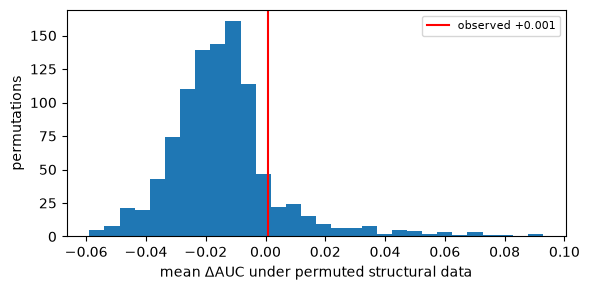

label null: 1000 permutations


,model,mean_auc,p_permutation
0,structural,0.6619,0.0170
1,functional,0.6882,0.0090
2,early_fusion,0.6946,0.0070
3,equal_weight,0.6866,0.0120
4,mkl,0.6890,0.0130
5,stacking,0.6576,0.0190
6,confounds_only,0.4868,0.5654


In [9]:
def load_chunks(name):
    """Combine every saved chunk of one null, or None if none have been computed yet."""
    folder = RESULTS / "permutation_tests" / f"{name}_{TAG}"
    chunks = sorted(folder.glob("chunk_*.csv")) if folder.exists() else []
    if not chunks:
        return None
    null = pd.concat([pd.read_csv(c) for c in chunks], ignore_index=True)
    if null["permutation"].duplicated().any():
        raise ValueError(f"overlapping permutation indices in {folder}")
    return null


block_null = load_chunks("structural_block")
label_null = load_chunks("labels")
beats_chance = None
p_block = None

if block_null is None:
    print("structural-block null: no chunks yet -> the verdict below stays pending")
else:
    p_block = permutation_p_value(primary_ci["mean"], block_null["statistic"])
    print(f"structural-block null: {len(block_null)} permutations, p = {p_block:.4f} "
          f"(smallest attainable: {1 / (len(block_null) + 1):.4f})")
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(block_null["statistic"], bins=30)
    ax.axvline(primary_ci["mean"], color="red", label=f"observed {primary_ci['mean']:+.3f}")
    ax.set(xlabel="mean ΔAUC under permuted structural data", ylabel="permutations")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

if label_null is None:
    print("label null: no chunks yet -> beats-chance tests pending")
else:
    observed = mean_auc_by_model(predictions)
    beats_chance = pd.DataFrame([{"model": m, "mean_auc": observed[m],
                                  "p_permutation": permutation_p_value(observed[m], label_null[m])}
                                 for m in MODELS if m in label_null.columns])
    print(f"label null: {len(label_null)} permutations")
    display(beats_chance.round(4))

## The prespecified decision
Applied by `classify_primary_result`, exactly as written in protocol §7.3 before any of this was run.

In [10]:
verdict = (classify_primary_result(primary_ci["mean"], primary_ci["ci_low"], primary_ci["ci_high"],
                                   p_block, delta, alpha)
           if p_block is not None else "pending: permutation test not yet run")
result = {"comparison": "mkl - functional", "n_participants": int(len(y)),
          "n_patients": int(y.sum()), "n_controls": int((y == 0).sum()),
          "n_features": {k: int(len(v)) for k, v in blocks.items()},
          "mean_delta_auc": primary_ci["mean"], "ci_low": primary_ci["ci_low"],
          "ci_high": primary_ci["ci_high"], "p_block_permutation": p_block,
          "n_permutations": int(len(block_null)) if block_null is not None else 0,
          "delta": delta, "alpha": alpha,
          "median_beta_structural": float(beta.median()), "result": verdict}
print(json.dumps(result, indent=2, default=float))

{
  "comparison": "mkl - functional",
  "n_participants": 82,
  "n_patients": 31,
  "n_controls": 51,
  "n_features": {
    "structural": 76,
    "functional": 4950,
    "confounds": 3
  },
  "mean_delta_auc": 0.0008917748917748969,
  "ci_low": -0.12870322219719915,
  "ci_high": 0.13048677198074893,
  "p_block_permutation": 0.11788211788211789,
  "n_permutations": 1000,
  "delta": 0.02,
  "alpha": 0.05,
  "median_beta_structural": 0.3,
  "result": "inconclusive"
}


## Figures and stability

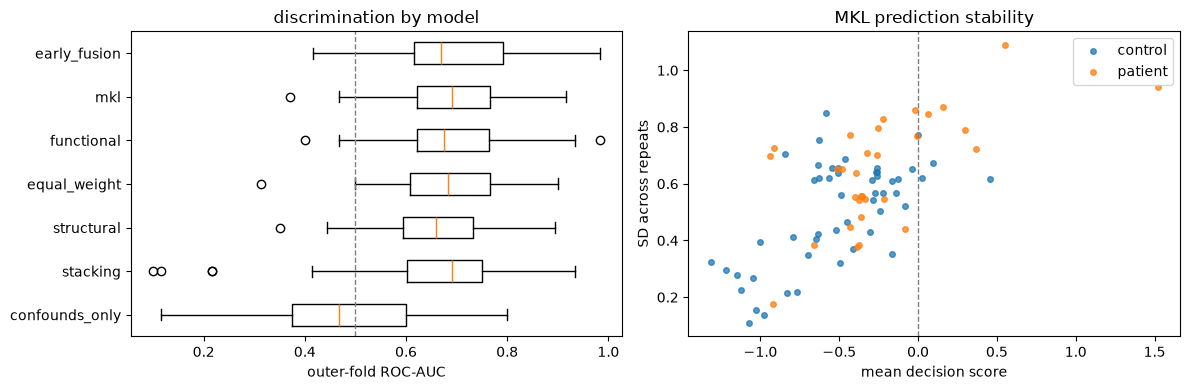

median score SD: 0.59; participants classified identically in every repeat: 14/82


In [11]:
order = folds.groupby("model")["auc"].mean().sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([folds.loc[folds["model"] == m, "auc"] for m in order], orientation="horizontal")
axes[0].set_yticks(range(1, len(order) + 1), order)
axes[0].axvline(0.5, color="grey", ls="--", lw=1)
axes[0].set(xlabel="outer-fold ROC-AUC", title="discrimination by model")

stability = prediction_stability(predictions, "mkl")
for label, name in [(0, "control"), (1, "patient")]:
    subset = stability[stability["y_true"] == label]
    axes[1].scatter(subset["mean_score"], subset["sd_score"], s=16, alpha=0.75, label=name)
axes[1].axvline(0, color="grey", ls="--", lw=1)
axes[1].set(xlabel="mean decision score", ylabel="SD across repeats", title="MKL prediction stability")
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"median score SD: {stability['sd_score'].median():.2f}; "
      f"participants classified identically in every repeat: "
      f"{int(stability['frac_predicted_patient'].isin([0, 1]).sum())}/{len(stability)}")

## Save everything

In [12]:
(RESULTS / "predictions").mkdir(parents=True, exist_ok=True)
(RESULTS / "metrics").mkdir(parents=True, exist_ok=True)
predictions.to_csv(RESULTS / "predictions" / f"predictions_{TAG}.csv", index=False)
selections.to_csv(RESULTS / "metrics" / f"selections_{TAG}.csv", index=False)
folds.to_csv(RESULTS / "metrics" / f"fold_metrics_{TAG}.csv", index=False)
summarize(folds).to_csv(RESULTS / "metrics" / f"summary_{TAG}.csv", index=False)
secondary.to_csv(RESULTS / "metrics" / f"comparisons_{TAG}.csv", index=False)
stability.to_csv(RESULTS / "metrics" / f"stability_{TAG}.csv", index=False)
np.savez_compressed(RESULTS / "predictions" / f"primal_weights_{TAG}.npz", **weights)
(RESULTS / "metrics" / f"primary_result_{TAG}.json").write_text(json.dumps(result, indent=2, default=float))
if beats_chance is not None:
    beats_chance.to_csv(RESULTS / "metrics" / f"beats_chance_{TAG}.csv", index=False)
# The null distributions themselves already live in results/permutation_tests/ as chunks.
print("saved:", *(p.name for p in sorted((RESULTS / "metrics").glob(f"*{TAG}*"))), sep="\n  ")

saved:
  beats_chance_multimodal.csv
  comparisons_multimodal.csv
  fold_metrics_multimodal.csv
  primary_result_multimodal.json
  selections_multimodal.csv
  stability_multimodal.csv
  summary_multimodal.csv


## How to read this
- **The verdict is the prespecified one.** It was fixed in protocol §7.3 before any multimodal result existed, so it cannot be renegotiated now.
- **A null result is informative.** If MKL does not beat functional connectivity, that is evidence that fusion adds no detectable value in this dataset under this design — which protocol §9 says in advance.
- **Check β before interpreting.** If MKL mostly selected β_structural = 0, it reduced to the functional model, and any difference is noise around that.
- **Sample size limits everything.** With roughly 30 patients, intervals are wide, and the structural features are volumes rather than cortical thickness (§3.2).